In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [2]:
signaling = pd.read_csv(
    "../datasets/processed/day22_signaling_results.csv"
)

print("Signaling:")
print(signaling)

Signaling:
                             Relationship  Correlation  Absolute_Correlation
0         Dividend Growth vs Total Return     0.113939              0.113939
1    Dividend Consistency vs Total Return          NaN                   NaN
2          Dividend Yield vs Total Return    -0.408903              0.408903
3  Dividend Growth vs Annual Stock Return     0.142030              0.142030


In [3]:
agency = pd.read_csv(
    "../datasets/processed/day23_agency_results.csv"
)

print("Agency Cost:")
print(agency)

Agency Cost:
                       Relationship  Correlation  Absolute_Correlation
0   Dividend Yield vs Profit Margin    -0.363757              0.363757
1             Dividend Yield vs ROA    -0.663797              0.663797
2    Dividend Yield vs Total Return    -0.322061              0.322061
3  Dividend Growth vs Profit Margin     0.267384              0.267384
4            Dividend Growth vs ROA     0.131932              0.131932


In [4]:
bird = pd.read_csv(
    "../datasets/processed/day24_bird_in_hand_results.csv"
)

print("Bird-in-Hand:")
print(bird)

Bird-in-Hand:
                                Relationship  Correlation  \
0             Dividend Yield vs Total Return    -0.408903   
1        Dividend Yield vs Return Volatility    -0.302716   
2       Dividend Consistency vs Total Return          NaN   
3  Dividend Consistency vs Return Volatility          NaN   
4            Dividend Growth vs Total Return     0.113939   
5       Dividend Growth vs Return Volatility     0.136493   

   Absolute_Correlation  
0              0.408903  
1              0.302716  
2                   NaN  
3                   NaN  
4              0.113939  
5              0.136493  


In [5]:
tax = pd.read_csv(
    "../datasets/processed/day25_tax_clientele_results.csv"
)

print("Tax/Clientele:")
print(tax)

Tax/Clientele:
                           Relationship  Correlation  Absolute_Correlation
0        Dividend Yield vs Total Return    -0.408903              0.408903
1   Dividend Yield vs Return Volatility    -0.302716              0.302716
2       Dividend Growth vs Total Return     0.113939              0.113939
3  Dividend Growth vs Return Volatility     0.136493              0.136493


In [6]:
importance = pd.read_csv(
    "../datasets/processed/day26_feature_importance.csv"
)

print("Feature Importance:")
print(importance)

Feature Importance:
                Feature  Coefficient  Normalized_Importance  \
0        dividend_yield    -5.239004               0.816370   
1       dividend_growth    -0.727658               0.113388   
2     return_volatility     0.450775               0.070242   
3  dividend_consistency     0.000000               0.000000   

   XGBoost_Importance  Overall_Importance  
0            0.369330            0.592850  
1            0.368466            0.240927  
2            0.262203            0.166223  
3            0.000000            0.000000  


In [9]:
files = [
    "../datasets/processed/day22_signaling_results.csv",
    "../datasets/processed/day23_agency_results.csv",
    "../datasets/processed/day24_bird_in_hand_results.csv",
    "../datasets/processed/day25_tax_clientele_results.csv",
    "../datasets/processed/day26_feature_importance.csv"
]

for file in files:
    print(f"{file} -> {os.path.exists(file)}")

../datasets/processed/day22_signaling_results.csv -> True
../datasets/processed/day23_agency_results.csv -> True
../datasets/processed/day24_bird_in_hand_results.csv -> True
../datasets/processed/day25_tax_clientele_results.csv -> True
../datasets/processed/day26_feature_importance.csv -> True


In [10]:
signaling_score = signaling[
    "Absolute_Correlation"
].mean()

print("Signaling Theory Score:",
      round(signaling_score, 4))

Signaling Theory Score: 0.2216


In [11]:
agency_score = agency[
    "Absolute_Correlation"
].mean()

print("Agency Cost Theory Score:",
      round(agency_score, 4))

Agency Cost Theory Score: 0.3498


In [12]:
bird_score = bird[
    "Absolute_Correlation"
].mean()

print("Bird-in-Hand Theory Score:",
      round(bird_score, 4))

Bird-in-Hand Theory Score: 0.2405


In [13]:
tax_score = tax[
    "Absolute_Correlation"
].mean()

print("Tax/Clientele Theory Score:",
      round(tax_score, 4))

Tax/Clientele Theory Score: 0.2405


In [14]:
theory_comparison = pd.DataFrame({
    "Theory": [
        "Signaling Theory",
        "Agency Cost Theory",
        "Bird-in-Hand Theory",
        "Tax/Clientele Theory"
    ],
    "Evidence_Score": [
        signaling_score,
        agency_score,
        bird_score,
        tax_score
    ]
})

theory_comparison = theory_comparison.sort_values(
    "Evidence_Score",
    ascending=False
).reset_index(drop=True)

theory_comparison["Rank"] = (
    theory_comparison.index + 1
)

print(theory_comparison.round(4))

                 Theory  Evidence_Score  Rank
0    Agency Cost Theory          0.3498     1
1   Bird-in-Hand Theory          0.2405     2
2  Tax/Clientele Theory          0.2405     3
3      Signaling Theory          0.2216     4


In [15]:
best_theory = theory_comparison.loc[
    theory_comparison["Evidence_Score"].idxmax(),
    "Theory"
]

best_score = theory_comparison.loc[
    theory_comparison["Evidence_Score"].idxmax(),
    "Evidence_Score"
]

print("Best-performing theory:", best_theory)
print("Evidence score:", round(best_score, 4))

Best-performing theory: Agency Cost Theory
Evidence score: 0.3498


In [16]:
top_feature = importance.iloc[0]["Feature"]
top_importance = importance.iloc[0]["Overall_Importance"]

print("Most important feature:", top_feature)
print("Importance:", round(top_importance, 4))

Most important feature: dividend_yield
Importance: 0.5929


In [17]:
theory_feature_mapping = pd.DataFrame({
    "Theory": [
        "Signaling Theory",
        "Agency Cost Theory",
        "Bird-in-Hand Theory",
        "Tax/Clientele Theory"
    ],
    "Key_Features": [
        "Dividend Growth, Dividend Yield",
        "Dividend Yield, Profit Margin, ROA",
        "Dividend Yield, Dividend Growth, Return Volatility",
        "Dividend Yield, Dividend Growth"
    ]
})

print(theory_feature_mapping)

                 Theory                                       Key_Features
0      Signaling Theory                    Dividend Growth, Dividend Yield
1    Agency Cost Theory                 Dividend Yield, Profit Margin, ROA
2   Bird-in-Hand Theory  Dividend Yield, Dividend Growth, Return Volati...
3  Tax/Clientele Theory                    Dividend Yield, Dividend Growth


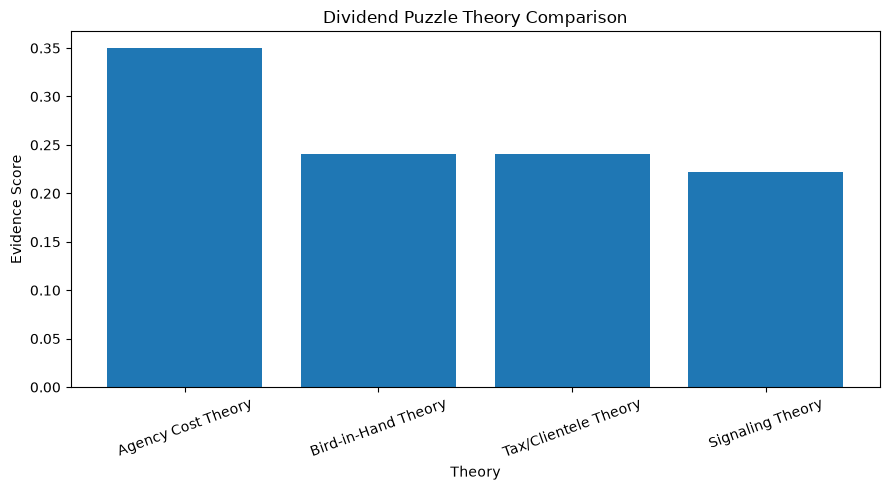

In [18]:
plt.figure(figsize=(9, 5))

plt.bar(
    theory_comparison["Theory"],
    theory_comparison["Evidence_Score"]
)

plt.xlabel("Theory")
plt.ylabel("Evidence Score")
plt.title("Dividend Puzzle Theory Comparison")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [19]:
theory_comparison.to_csv(
    "../datasets/processed/day27_theory_comparison.csv",
    index=False
)

print("Theory comparison saved successfully!")

Theory comparison saved successfully!


In [20]:
theory_feature_mapping.to_csv(
    "../datasets/processed/day27_theory_feature_mapping.csv",
    index=False
)

print("Theory feature mapping saved successfully!")

Theory feature mapping saved successfully!


In [21]:
print(theory_comparison.round(4))

                 Theory  Evidence_Score  Rank
0    Agency Cost Theory          0.3498     1
1   Bird-in-Hand Theory          0.2405     2
2  Tax/Clientele Theory          0.2405     3
3      Signaling Theory          0.2216     4


In [22]:
print("Best theory:", best_theory)
print("Best score:", round(best_score, 4))

Best theory: Agency Cost Theory
Best score: 0.3498
